# Datenanalyse mit SQL & Python - Tag 5: Übungen

**Freitag:** Abschlussprojekt & Storytelling mit Daten  
**Warm-up:** 30 Minuten EDA mit Household-Budget-Daten  
**Vormittag:** Data Storytelling - Ergebnisse klar und überzeugend präsentieren  
**Nachmittag:** Gruppenprojekt mit messy data: von der Business-Frage zur Empfehlung


## Lernziele

In diesen Übungen trainierst du:

- eine schnelle EDA mit einem bekannten Datensatz durchzuführen
- Analyseergebnisse in eine verständliche Datenstory zu übersetzen
- im Rollenspiel Business-Fragen und KPIs zu definieren
- ein messy Dataset eigenständig zu bereinigen
- mit SQL und Python Analysefragen zu beantworten
- Erkenntnisse und Empfehlungen klar zu präsentieren


## Hinweis zum Ablauf

Der vollständige Tagesablauf steht im Hauptnotebook `Day_5_Data_Analytics_SQL_Python.ipynb`.

Dieses Übungsnotebook enthält die konkreten Arbeitsaufträge für Warm-up und Gruppenprojekt. Die Storytelling-Methodik wird im Hauptnotebook erklärt und hier direkt auf das Projekt angewendet.


## Einrichtung & Importe

Führe diese Zelle zuerst aus. Sie lädt das Household Budget für den Warm-up und bereitet die Quellen für das Gruppenprojekt vor.


In [17]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 100)


BUDGET_PATH = 'https://raw.githubusercontent.com/chiaoya/Data_to_Decision_with_SQL_Python/refs/heads/main/course_data/household_budget.csv'

budget_df = pd.read_csv(BUDGET_PATH)
budget_df['date'] = pd.to_datetime(budget_df['date'])
budget_df['month'] = budget_df['date'].dt.strftime('%Y-%m')

conn = sqlite3.connect(':memory:')
budget_df.to_sql('budget', conn, index=False, if_exists='replace')


def read_messy_csv(path_or_url):
    # Some project files are not clean UTF-8/comma CSVs. Try common encodings
    # and separators, and skip malformed rows so students can start cleaning.
    encodings = ['utf-8', 'utf-8-sig', 'latin-1', 'cp1252']
    separators = [None, ',', ';', '\t']
    best_df = None
    best_meta = None
    last_error = None

    for encoding in encodings:
        for sep in separators:
            try:
                df = pd.read_csv(
                    path_or_url,
                    encoding=encoding,
                    sep=sep,
                    engine='python',
                    on_bad_lines='skip'
                )
                if best_df is None or df.shape[1] > best_df.shape[1]:
                    best_df = df
                    best_meta = (encoding, sep)
                if df.shape[1] > 1:
                    used_sep = 'auto' if sep is None else repr(sep)
                    print(f'CSV geladen mit encoding={encoding}, sep={used_sep}, shape={df.shape}')
                    return df
            except (UnicodeDecodeError, pd.errors.ParserError) as error:
                last_error = error

    if best_df is not None:
        encoding, sep = best_meta
        used_sep = 'auto' if sep is None else repr(sep)
        print(f'CSV geladen mit encoding={encoding}, sep={used_sep}, shape={best_df.shape}')
        return best_df

    raise last_error


MESSY_PROJECT_DATASETS = {
    'Warehouse': 'https://raw.githubusercontent.com/eyowhite/Messy-dataset/main/warehouse_messy_data.csv',
    'IMDB': 'https://raw.githubusercontent.com/eyowhite/Messy-dataset/main/messy_IMDB_dataset.csv',
    'Healthcare': 'https://raw.githubusercontent.com/eyowhite/Messy-dataset/main/healthcare_messy_data.csv',
}

print('budget_df:', budget_df.shape)
budget_df.head()


budget_df: (60, 6)


,date,category,description,amount,type,month
0,2024-02-01,Entertainment,Entertainment payment,-265,Expense,2024-02
1,2024-01-19,Rent,Rent payment,-191,Expense,2024-01
2,2024-03-09,Transport,Transport payment,-196,Expense,2024-03
3,2024-02-18,Dining,Dining payment,-173,Expense,2024-02
4,2024-03-13,Utilities,Utilities payment,-227,Expense,2024-03


## Teil A: 30-Minuten Warm-up - EDA mit Household Budget

In diesem Warm-up geht es nicht um Data Cleaning. Der Datensatz ist bekannt und sauber genug. Ziel ist, schnell wieder in die Analyse-Logik zu kommen:

- Daten verstehen
- Kennzahlen berechnen
- Gruppen vergleichen
- ein Diagramm erstellen
- Erkenntnisse formulieren


### Übung A1: Überblick (ca. 5 Minuten)

**Aufgabe:** Prüfe Form, Spalten, Datentypen und erste Zeilen.


In [2]:
print('Form:', budget_df.shape)
print('Spalten:', budget_df.columns.tolist())
budget_df.info()
budget_df.head()


Form: (60, 6)
Spalten: ['date', 'category', 'description', 'amount', 'type', 'month']
<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         60 non-null     datetime64[us]
 1   category     60 non-null     str           
 2   description  60 non-null     str           
 3   amount       60 non-null     int64         
 4   type         60 non-null     str           
 5   month        60 non-null     str           
dtypes: datetime64[us](1), int64(1), str(4)
memory usage: 2.9 KB


,date,category,description,amount,type,month
0,2024-02-01,Entertainment,Entertainment payment,-265,Expense,2024-02
1,2024-01-19,Rent,Rent payment,-191,Expense,2024-01
2,2024-03-09,Transport,Transport payment,-196,Expense,2024-03
3,2024-02-18,Dining,Dining payment,-173,Expense,2024-02
4,2024-03-13,Utilities,Utilities payment,-227,Expense,2024-03


### Übung A2: Zentrale Kennzahlen (ca. 7 Minuten)

**Aufgabe:** Berechne Gesamtausgaben, Gesamteinnahmen und Netto-Betrag.


In [3]:
total_expenses = budget_df.loc[budget_df['type'] == 'Expense', 'amount'].sum()
total_income = budget_df.loc[budget_df['type'] == 'Income', 'amount'].sum()
net_amount = budget_df['amount'].sum()

print('Gesamtausgaben:', total_expenses)
print('Gesamteinnahmen:', total_income)
print('Netto-Betrag:', net_amount)


Gesamtausgaben: -7934
Gesamteinnahmen: 21537
Netto-Betrag: 13603


### Übung A3: Ausgaben nach Kategorie (ca. 8 Minuten)

**Aufgabe:** Welche Kategorien verursachen die höchsten Ausgaben?


In [5]:
expenses_by_category = (
    budget_df[budget_df['type'] == 'Expense']
    .groupby('category')['amount']
    .sum()
    .abs()
    .sort_values(ascending=False)
)
expenses_by_category


category
Dining           2237
Entertainment    1812
Rent             1352
Utilities        1081
Transport         784
Groceries         668
Name: amount, dtype: int64

### Übung A4: Monatsanalyse (ca. 5 Minuten)

**Aufgabe:** Berechne den Netto-Betrag pro Monat.


In [6]:
monthly_budget = (
    budget_df
    .groupby('month')['amount']
    .sum()
    .reset_index(name='netto')
)
monthly_budget


,month,netto
0,2024-01,8985
1,2024-02,1991
2,2024-03,2627


### Übung A5: Visualisierung und Erkenntnisse (ca. 5 Minuten)

**Aufgabe:** Erstelle ein Diagramm und formuliere zwei kurze Erkenntnisse.


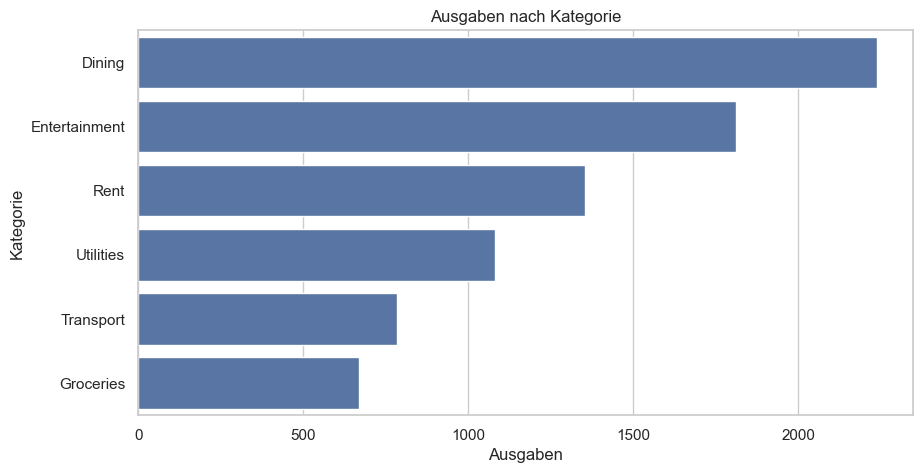

In [7]:
plot_data = expenses_by_category.reset_index()
plot_data.columns = ['category', 'expenses']

sns.barplot(data=plot_data, x='expenses', y='category')
plt.title('Ausgaben nach Kategorie')
plt.xlabel('Ausgaben')
plt.ylabel('Kategorie')
plt.show()


In [8]:
warmup_insights = [
    'Erkenntnis 1: ...',
    'Erkenntnis 2: ...'
]

for insight in warmup_insights:
    print('-', insight)


- Erkenntnis 1: ...
- Erkenntnis 2: ...


## Teil B: Gruppenprojekt - Messy Data Challenge

Ab jetzt arbeitet ihr in Gruppen. Die Storytelling-Logik aus dem Hauptnotebook wird direkt auf ein messy Dataset angewendet.

Jede Gruppe waehlt **einen** Datensatz:

| Dataset | Business-Kontext | Typische Entscheidung |
|---|---|---|
| Warehouse | Lagerbestand und Nachbestellung | Welche Produkte oder Kategorien muessen priorisiert werden? |
| IMDB | Filmportfolio und Erfolgsfaktoren | Welche Filmtypen sind besonders attraktiv? |
| Healthcare | Patientendaten, Kosten und Qualitaet | Wo entstehen hohe Kosten, Wartezeiten oder Risiken? |


### Schritt B1: Thema ziehen und Dataset waehlen (ca. 10 Minuten)

Jede Gruppe zieht oder waehlt zuerst **ein** Thema. Danach setzt ihr `selected_project_dataset` passend.

| Dataset | Business-Kontext | Typische Entscheidung |
|---|---|---|
| Warehouse | Lagerbestand und Nachbestellung | Welche Produkte oder Kategorien muessen priorisiert werden? |
| IMDB | Filmportfolio und Erfolgsfaktoren | Welche Filmtypen sind besonders attraktiv? |
| Healthcare | Patientendaten, Kosten und Qualitaet | Wo entstehen hohe Kosten, Wartezeiten oder Risiken? |


In [ ]:
selected_project_dataset = 'Warehouse'  # Optionen: 'Warehouse', 'IMDB', 'Healthcare'
project_url = MESSY_PROJECT_DATASETS[selected_project_dataset]

project_raw = read_messy_csv(project_url)
print('Gewaehltes Dataset:', selected_project_dataset)
print('Quelle:', project_url)
print('Form:', project_raw.shape)
project_raw.head()


### Schritt B2: Daten kurz verstehen und Projektfrage formulieren (ca. 20 Minuten)

Schaut euch **euer** Dataset an und formuliert danach Business-Frage, KPIs und Analysefragen.

Achtet beim ersten Blick auf:

- Welche Spalten gibt es?
- Welche Spalten klingen wie KPIs?
- Welche Spalten sind wahrscheinlich messy?
- Welche Business-Frage waere realistisch in der verbleibenden Zeit?


In [ ]:
print('Spalten:')
print(project_raw.columns.tolist())

print('
Datentypen:')
print(project_raw.dtypes)

print('
Fehlende Werte:')
print(project_raw.isna().sum().sort_values(ascending=False).head(15))

project_raw.head()


### Business-Fragen und KPI-Ideen nach Dataset

| Dataset | Moegliche Business-Fragen | Moegliche KPIs |
|---|---|---|
| Warehouse | Welche Produkte haben hohes Bestandsrisiko? Welche Kategorien binden viel Kapital? Wo sollte nachbestellt werden? | Stock quantity, reorder level, stockout risk, inventory value, unit cost, category share |
| IMDB | Welche Genres schneiden gut ab? Welche Faktoren haengen mit hohem Rating oder vielen Votes zusammen? Welche Filmtypen waeren fuer ein Portfolio attraktiv? | Rating, votes, gross/revenue, runtime, year, genre, certificate |
| Healthcare | Welche Gruppen verursachen hohe Kosten? Wo sind Wartezeiten oder Aufenthaltsdauer auffaellig? Welche Faktoren koennten Qualitaet oder Risiko beeinflussen? | Cost, waiting time, length of stay, age, diagnosis/group, readmission/risk indicator |

Waehlt **eine** Business-Frage und maximal **3 KPIs**. Weniger ist hier besser.


In [ ]:
business_context = '...'
decision_to_support = '...'

business_question = '...'

kpis = [
    'KPI 1: ...',
    'KPI 2: ...',
    'KPI 3: ...'
]

analysis_questions = [
    'Frage 1: ...',
    'Frage 2: ...',
    'Frage 3: ...'
]

print('Business-Kontext:', business_context)
print('Entscheidung:', decision_to_support)
print('Business-Frage:', business_question)
print('KPIs:', kpis)
print('Analysefragen:', analysis_questions)


### Schritt B3: Cleaning-Plan festlegen (ca. 10 Minuten)

Bevor ihr bereinigt, entscheidet: Welche Cleaning-Schritte sind fuer eure Business-Frage wirklich wichtig?

| Dataset | Typische Cleaning-Richtung |
|---|---|
| Warehouse | Spaltennamen vereinheitlichen, Zahlen aus Text konvertieren, fehlende Bestandswerte pruefen, Duplikate entfernen, Kategorien vereinheitlichen |
| IMDB | Rating/Votes/Gross/Runtime numerisch machen, Jahr bereinigen, Genres trennen oder vereinheitlichen, fehlende Werte markieren |
| Healthcare | Kosten/Wartezeiten/Aufenthaltsdauer numerisch machen, Datums- oder Altersfelder pruefen, Kategorien vereinheitlichen, fehlende Werte dokumentieren |

Schreibt jede Cleaning-Entscheidung so auf, dass eine andere Person sie nachvollziehen kann.


### Schritt B4: Data Cleaning (ca. 45-60 Minuten)

Erstellt `project_clean` und dokumentiert eure wichtigsten Entscheidungen.


In [ ]:
project_clean = project_raw.copy()

# 1) Spaltennamen vereinheitlichen
project_clean.columns = (
    project_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)

# 2) Textspalten bereinigen
text_cols = project_clean.select_dtypes(include=['object']).columns
for col in text_cols:
    project_clean[col] = project_clean[col].astype('string').str.strip()

# 3) Leere Strings in fehlende Werte umwandeln
project_clean = project_clean.replace(r'^\s*$', pd.NA, regex=True)

# 4) Duplikate entfernen
project_clean = project_clean.drop_duplicates()

print('Form vorher:', project_raw.shape)
print('Form nachher:', project_clean.shape)
project_clean.head()


In [ ]:
# Optional: Kandidaten fuer numerische Konvertierung pruefen
for col in project_clean.columns:
    if project_clean[col].dtype == 'string' or project_clean[col].dtype == 'object':
        numeric_candidate = pd.to_numeric(
            project_clean[col].astype('string').str.replace(',', '', regex=False).str.replace('$', '', regex=False),
            errors='coerce'
        )
        numeric_share = numeric_candidate.notna().mean()
        if numeric_share > 0.6:
            print(col, '-> numeric candidate:', round(numeric_share, 2))


In [ ]:
cleaning_decisions = [
    'Cleaning-Entscheidung 1: ...',
    'Cleaning-Entscheidung 2: ...',
    'Cleaning-Entscheidung 3: ...'
]

for decision in cleaning_decisions:
    print('-', decision)


### Schritt B5: SQL-Fragen beantworten (ca. 25-30 Minuten)

Speichert `project_clean` in SQLite und beantwortet 2-3 Fragen mit SQL.

| Dataset | SQL-Ideen |
|---|---|
| Warehouse | `GROUP BY category`, Top-Produkte nach stock/inventory value, Produkte unter reorder level, `HAVING` fuer Risikogruppen |
| IMDB | `GROUP BY genre/certificate/year`, Top-Filme nach rating/votes, Durchschnittsrating pro Genre, `HAVING COUNT(*) >= ...` |
| Healthcare | `GROUP BY diagnosis/department/age_group`, Durchschnittskosten, Wartezeit nach Gruppe, Gruppen mit hoher Fallzahl und hohen Kosten |


In [ ]:
conn = sqlite3.connect(':memory:')
project_clean.to_sql('project_data', conn, index=False, if_exists='replace')

project_clean.columns.tolist()


In [ ]:
query = '''
SELECT *
FROM project_data
LIMIT 10;
'''

sql_result_1 = pd.read_sql_query(query, conn)
sql_result_1


In [ ]:
# SQL-Frage 1: Passe Spaltennamen an euer Dataset an.
# Ersetze group_column durch eine echte Spalte, z. B. category, genre oder department.
query_template = '''
SELECT
    group_column,
    COUNT(*) AS row_count
FROM project_data
GROUP BY group_column
ORDER BY row_count DESC
LIMIT 10;
'''

print(query_template)


### Schritt B6: Python/Pandas EDA (ca. 25-30 Minuten)

Nutzt Tag 3 und Tag 4 als Werkzeugkasten:

| Analyseziel | Pandas-Idee |
|---|---|
| Kategorien vergleichen | `.groupby(...).agg(...)`, `.sort_values()` |
| Neue KPI bauen | neue Spalte mit Berechnung, z. B. `inventory_value = stock * unit_cost` |
| Verteilung pruefen | `.describe()`, Histogramm, Boxplot |
| Zusammenhaenge pruefen | `.corr()`, Scatterplot |
| Zeit oder Jahr analysieren | Datums-/Jahr-Spalte extrahieren, `.groupby()` nach Zeitraum |


In [ ]:
# Numerische Spalten pruefen
numeric_project = project_clean.select_dtypes(include='number')
numeric_project.describe().T


In [ ]:
# Kategoriale Spalten pruefen
categorical_project = project_clean.select_dtypes(include=['object', 'string'])
for col in categorical_project.columns[:5]:
    print()
    print(col)
    print(project_clean[col].value_counts(dropna=False).head(10))


In [ ]:
# Beispiel: erste numerische Spalte visualisieren
if len(numeric_project.columns) > 0:
    selected_col = numeric_project.columns[0]
    plt.hist(project_clean[selected_col].dropna(), bins=20)
    plt.title(f'Verteilung: {selected_col}')
    plt.xlabel(selected_col)
    plt.ylabel('Anzahl')
    plt.show()
else:
    print('Keine numerischen Spalten gefunden. Waehlt eine kategoriale Analyse.')


### Schritt B7: Visualisierung gezielt auswaehlen (ca. 15 Minuten)

| Aussage | Geeignete Visualisierung |
|---|---|
| Eine Kategorie ist groesser/teurer/riskanter als andere | Balkendiagramm |
| Eine Kennzahl streut stark oder hat Ausreisser | Histogramm oder Boxplot |
| Zwei numerische Kennzahlen haengen zusammen | Scatterplot |
| Werte veraendern sich ueber Zeit/Jahr | Liniendiagramm |
| Gruppen bestehen aus mehreren Anteilen | gestapeltes Balkendiagramm |

Formuliert den Titel als Aussage: nicht `Rating nach Genre`, sondern `Genre X hat das hoechste durchschnittliche Rating`.


### Schritt B8: Storytelling und Praesentation (ca. 20-30 Minuten)

Verdichtet eure Analyse in eine kurze Praesentation.

Mindestens enthalten:

- Business-Frage und Zielgruppe
- Datenbasis und Datenqualitaet
- wichtigste Cleaning-Entscheidungen
- 2-3 zentrale Findings im S-C-R-Stil
- 1-2 Empfehlungen
- Grenzen der Analyse
- naechster Schritt


In [ ]:
findings = [
    'S: ... | C: ... | R: ...',
    'S: ... | C: ... | R: ...'
]

recommendations = [
    'Empfehlung 1: ...',
    'Empfehlung 2: ...'
]

limitations = [
    'Grenze der Analyse: ...'
]

next_step = 'Naechster Schritt: ...'

for item in findings:
    print('-', item)
for item in recommendations:
    print('-', item)
for item in limitations:
    print('-', item)
print(next_step)


## Praesentations-Checkliste

Vor der Praesentation pruefen:

- Ist die Business-Frage klar?
- Sind die KPIs passend zur Frage?
- Sind Cleaning-Entscheidungen nachvollziehbar?
- Sind SQL- und Python-Ergebnisse konsistent?
- Unterstuetzen die Diagramme die Empfehlung?
- Wird mindestens eine Grenze der Analyse ehrlich genannt?


## Abschlussreflexion

Diskutiert nach den Praesentationen:

1. Welche Gruppe hatte die klarste Business-Frage?
1. Welche Cleaning-Entscheidung war besonders wichtig?
1. Welche Visualisierung war am ueberzeugendsten?
1. Welche Empfehlung waere in der Praxis direkt testbar?


## Musterlösungen

Diese Lösungen sind als Referenz gedacht. Im Gruppenprojekt sind mehrere richtige Wege möglich, solange Business-Frage, Cleaning, Analyse und Empfehlung nachvollziehbar zusammenpassen.


### Lösungen Teil A: EDA mit Household Budget

In [ ]:
# A1
budget_df.head()
budget_df.info()

# A2
total_income = budget_df.loc[budget_df['type'] == 'Income', 'amount'].sum()
total_expenses = budget_df.loc[budget_df['type'] == 'Expense', 'amount'].sum()
net_amount = total_income - total_expenses

print('Income:', total_income)
print('Expenses:', total_expenses)
print('Net amount:', net_amount)

# A3
expenses_by_category = (
    budget_df
    .loc[budget_df['type'] == 'Expense']
    .groupby('category')['amount']
    .sum()
    .sort_values(ascending=False)
)
expenses_by_category

# A4
monthly_budget = (
    budget_df
    .assign(signed_amount=lambda df: np.where(df['type'] == 'Income', df['amount'], -df['amount']))
    .groupby('month')['signed_amount']
    .sum()
    .sort_index()
)
monthly_budget


In [ ]:
# A5
plot_data = expenses_by_category.reset_index()
plot_data.columns = ['category', 'amount']

sns.barplot(data=plot_data, x='amount', y='category')
plt.title('Ausgaben nach Kategorie')
plt.xlabel('Betrag')
plt.ylabel('Kategorie')
plt.show()

warmup_insights = [
    f'Groesste Ausgabenkategorie: {expenses_by_category.index[0]}',
    f'Gesamtausgaben: {total_expenses:.2f}',
    f'Netto-Betrag: {net_amount:.2f}',
]
warmup_insights


### Lösungen Teil B: Projekt-Rahmen

Im Gruppenprojekt gibt es keine einzige Musterloesung. Eine gute Loesung ist nachvollziehbar, wenn sie diese Kriterien erfuellt:

- Business-Frage und KPI passen zusammen
- Cleaning-Entscheidungen sind dokumentiert
- SQL liefert mindestens eine aggregierte Reporting-Tabelle
- Python/Pandas liefert mindestens eine EDA-Tabelle und eine Visualisierung
- Findings enthalten S-C-R: Beobachtung, Kontext, Empfehlung
- Grenzen der Analyse werden klar genannt


In [ ]:
# Beispielhafter Projekt-Start
selected_project_dataset = 'Warehouse'
project_raw = read_messy_csv(MESSY_PROJECT_DATASETS[selected_project_dataset])

project_clean = project_raw.copy()
project_clean.columns = (
    project_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)

for col in project_clean.select_dtypes(include=['object']).columns:
    project_clean[col] = project_clean[col].astype('string').str.strip()

project_clean = project_clean.replace(r'^\s*$', pd.NA, regex=True).drop_duplicates()
project_clean.head()


In [ ]:
# Beispielhafte SQL-Analyse fuer das Projekt
conn = sqlite3.connect(':memory:')
project_clean.to_sql('project', conn, index=False, if_exists='replace')

query = 'SELECT * FROM project LIMIT 10;'
pd.read_sql_query(query, conn)


In [ ]:
# Beispielhafte EDA fuer das Projekt
numeric_project = project_clean.select_dtypes(include='number')
categorical_project = project_clean.select_dtypes(include=['object', 'string'])

display(numeric_project.describe().T)
display(categorical_project.nunique().sort_values(ascending=False).head(10))

if len(numeric_project.columns) > 0:
    selected_col = numeric_project.columns[0]
    plt.hist(project_clean[selected_col].dropna(), bins=20)
    plt.title(f'Verteilung: {selected_col}')
    plt.xlabel(selected_col)
    plt.ylabel('Anzahl')
    plt.show()
